# Community detection (Girvan-Newman)
## Example 1: AL city metworks

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

node_table = pd.read_csv("./data/Alabama_city_network/node_table.csv")
edge_table = pd.read_csv("./data/Alabama_city_network/edge_table.csv")

graph = nx.from_pandas_edgelist(edge_table, source="Source", target="Target", edge_attr="Weight")

size_dict = dict(zip(node_table["Id"], node_table["Size"]))
nx.set_node_attributes(graph, size_dict, "size")

In [33]:
# inspect the graph

print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())
# print("\nNodes:", graph.nodes())
# print("\nEdges:", graph.edges())


Number of nodes: 232
Number of edges: 4448


In [4]:
# community detection using Girvan-Newman method

communities = list(nx.community.girvan_neswman(graph))

# Modularity -> measures the strength of division of a network into modules
modularity_df = pd.DataFrame(
    [
        [k + 1, nx.community.modularity(graph, communities[k])]
        for k in range(len(communities))
    ],
    columns=["k", "modularity"],
)


In [7]:
modularity_df.nlargest(n=5, columns="modularity")

,k,modularity
184,185,0.051446
185,186,0.051122
186,187,0.051051
187,188,0.049554
188,189,0.048589


In [10]:
len(communities[185][1])

1

In [29]:

tmp_ = modularity_df.copy()
tmp_['singletons'] = tmp_['k'].apply(lambda x: sum([len(i)==1 for i in communities[x-1]]))
tmp_['average_community_size'] = tmp_['k'].apply(lambda x: np.mean([len(i) for i in communities[x-1]]))


<Axes: xlabel='k', ylabel='modularity'>

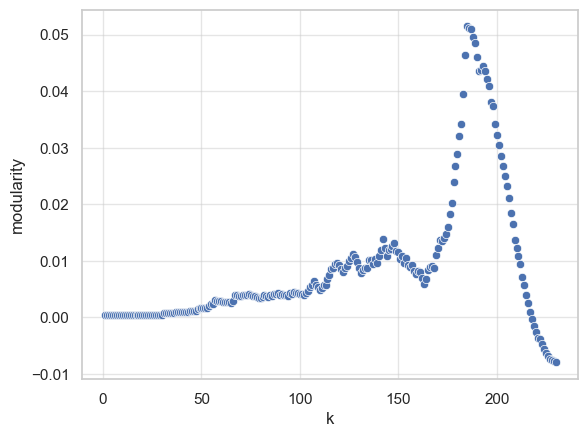

In [39]:
sns.set_theme(style="whitegrid")
sns.scatterplot(data=tmp_, x='k', y='modularity')

In [42]:
[len(i) for i in communities[60]]

[168,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1]

## Example 2

In [57]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

edge_list = [(1,2), (1,3), (1,4), (2,3), (3,4), (4,5),
             (5,6), (5,7), (6,9), (6,8), (8,9)]

graph_2 = nx.Graph()
graph_2.add_edges_from(edge_list)

In [58]:
print("Number of nodes:", graph_2.number_of_nodes())
print("Number of edges:", graph_2.number_of_edges())

Number of nodes: 9
Number of edges: 11


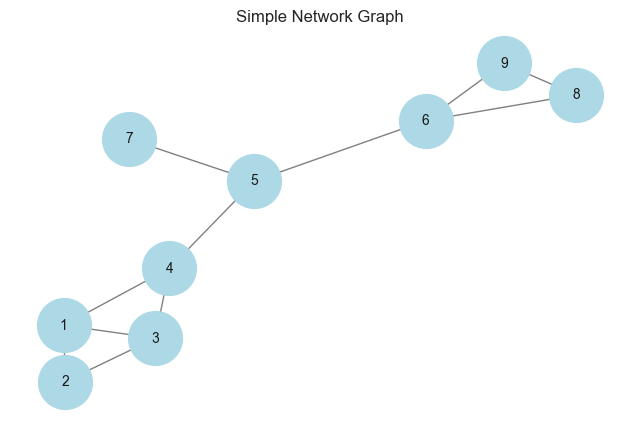

In [73]:

sns.set_theme(style="white", font_scale=1)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

pos = nx.spring_layout(graph_2, seed=1)

nx.draw(
    graph_2,
    pos,
    with_labels=True,
    node_size=1500,
    node_color="lightblue",
    font_size=10,
    edge_color="gray", ax=ax
)

plt.title("Simple Network Graph")
plt.show()

In [52]:
# community detection using Girvan-Newman method

communities_2 = list(nx.community.girvan_newman(graph_2))

# Modularity -> measures the strength of division of a network into modules
modularity_df_2 = pd.DataFrame(
    [
        [k + 1, nx.community.modularity(graph_2, communities_2[k])]
        for k in range(len(communities_2))
    ],
    columns=["k", "modularity"],
)

# compute the numbers of singleton communities and average community size
modularity_df_2['singletons'] = modularity_df_2['k'].apply(lambda x: sum([len(i)==1 for i in communities_2[x-1]]))
modularity_df_2['average_community_size'] = modularity_df_2['k'].apply(lambda x: np.mean([len(i) for i in communities_2[x-1]]))

In [75]:
[print(community) for community in communities_2]

({1, 2, 3, 4}, {5, 6, 7, 8, 9})
({1, 2, 3, 4}, {5, 7}, {8, 9, 6})
({1, 3, 4}, {2}, {5, 7}, {8, 9, 6})
({1}, {2}, {3, 4}, {5, 7}, {8, 9, 6})
({1}, {2}, {3}, {4}, {5, 7}, {8, 9, 6})
({1}, {2}, {3}, {4}, {5}, {8, 9, 6}, {7})
({1}, {2}, {3}, {4}, {5}, {6}, {7}, {8, 9})
({1}, {2}, {3}, {4}, {5}, {6}, {7}, {9}, {8})


[None, None, None, None, None, None, None, None]

In [62]:
chosen_communities = communities_2[1]
node_to_comm = {}
for i, comm in enumerate(chosen_communities):
    for node in comm:
        node_to_comm[node] = i

colors = []
for node in graph_2.nodes():
    colors.append(node_to_comm[node])


Text(0.5, 1.0, 'Communities (Girvan–Newman)')

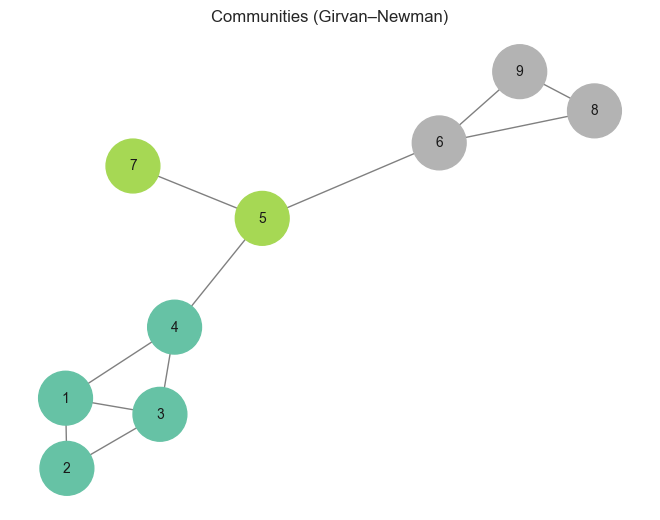

In [74]:

pos = nx.spring_layout(graph_2, seed=1)

nx.draw(
    graph_2,
    pos,
    node_color=colors,
    cmap=plt.cm.Set2,   # nice categorical colors
    with_labels=True,
    node_size=1500,
    font_size=10,
    edge_color="gray"
)

plt.title("Communities (Girvan–Newman)")
